# Data Quality – Missing Values
**Course:** Data & Analytics | Prof. Dr. Sonja Schneider  
**Institution:** Technische Hochschule Nürnberg Georg Simon Ohm  

**Contributors:**
- Danny Schönhals
- Athithya Mariyanayagam

## Dataset
**Autonomous Vehicle Survey of Bicyclists and Pedestrians in Pittsburgh (2019)**

Load the survey data for 2019 and inspect its structure before proceeding with the tasks.

In [33]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.experimental import enable_iterative_imputer  # must come before IterativeImputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

%matplotlib inline

In [34]:
# Load the 2019 survey data
df_av = pd.read_csv("data/av_survey_data/avsurvey2019data.csv", encoding="latin-1")
print(f"Shape: {df_av.shape}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_av.head()


Shape: (795, 23)


,RespondentID,StartDate,EndDate,FamiliarityNews,FamiliarityTech,SharedCyclist,SharedPedestrian,SafeAv,SafeHuman,AvImpact,ProvingGround,Speed25Mph,TwoEmployeesAv,SchoolZoneManual,ShareTripData,SharePerformanceData,ReportSafetyIncident,ArizonaCrash,ZipCode,BikePghMember,AutoOwner,SmartphoneOwner,Age
0,10505419886,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,Yes,4.0,2.0,Significantly Better,Approve,No,Not sure,No,Not sure,Yes,Yes,No change,15212,No,Yes,Yes,25-34
1,10505138734,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,No,5.0,4.0,Significantly Better,Neutral,No,No,No,No,Yes,Not sure,No change,15232,Not sure,Yes,Yes,25-34
2,10504803283,2/1/2019,2/1/2019,To a moderate extent,Somewhat familiar,Yes,Yes,1.0,4.0,Significantly Worse,Disapprove,Not sure,Yes,No,No,No,Not sure,Significantly more negative opinion,NaN,No,No,No,NaN
3,10504337177,2/1/2019,2/1/2019,To a moderate extent,Extremely familiar,Yes,Yes,2.0,3.0,Slightly Worse,Disapprove,Yes,Yes,Yes,No,Yes,Yes,No change,15136,No,No,Yes,55-64
4,10504261546,2/1/2019,2/1/2019,To a moderate extent,Mostly familiar,Yes,No,5.0,3.0,Slightly Better,Neutral,No,No,Not sure,Yes,Yes,No,No change,15201,Yes,No,Yes,35-44


In [35]:
df_av.describe

<bound method NDFrame.describe of      RespondentID  StartDate    EndDate       FamiliarityNews  \
0     10505419886   2/2/2019   2/2/2019  To a moderate extent   
1     10505138734   2/2/2019   2/2/2019  To a moderate extent   
2     10504803283   2/1/2019   2/1/2019  To a moderate extent   
3     10504337177   2/1/2019   2/1/2019  To a moderate extent   
4     10504261546   2/1/2019   2/1/2019  To a moderate extent   
..            ...        ...        ...                   ...   
790   10470569905  1/16/2019  1/16/2019  To a moderate extent   
791   10470569171  1/16/2019  1/16/2019  To a moderate extent   
792   10470532863  1/16/2019  1/16/2019  To a moderate extent   
793   10470438828  1/16/2019  1/16/2019        To some extent   
794   10468563638  1/15/2019  1/15/2019     To a large extent   

        FamiliarityTech SharedCyclist SharedPedestrian  SafeAv  SafeHuman  \
0     Somewhat familiar           Yes              Yes     4.0        2.0   
1     Somewhat familiar        

In [36]:
df_av.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RespondentID          795 non-null    int64  
 1   StartDate             795 non-null    object 
 2   EndDate               795 non-null    object 
 3   FamiliarityNews       794 non-null    object 
 4   FamiliarityTech       794 non-null    object 
 5   SharedCyclist         792 non-null    object 
 6   SharedPedestrian      793 non-null    object 
 7   SafeAv                787 non-null    float64
 8   SafeHuman             792 non-null    float64
 9   AvImpact              788 non-null    object 
 10  ProvingGround         792 non-null    object 
 11  Speed25Mph            792 non-null    object 
 12  TwoEmployeesAv        792 non-null    object 
 13  SchoolZoneManual      793 non-null    object 
 14  ShareTripData         793 non-null    object 
 15  SharePerformanceData  7

In [37]:
from scipy import stats

# Missing counts per column
missing = df_av.isnull().sum() # count the number of missing values in each column
missing_pct = (missing / len(df_av) * 100).round(1) # calculate percentage of missing values and round to 1 decimal place
miss_summary = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
miss_summary = miss_summary[miss_summary['n_missing'] > 0].sort_values('n_missing', ascending=False) # filter to only include columns with missing values and sort by number of missing values
miss_summary

,n_missing,pct_missing
ZipCode,32,4.0
SafeAv,8,1.0
BikePghMember,8,1.0
AvImpact,7,0.9
Age,7,0.9
SharePerformanceData,4,0.5
SmartphoneOwner,4,0.5
SharedCyclist,3,0.4
ProvingGround,3,0.4
ArizonaCrash,3,0.4


### Visualisations 1a)

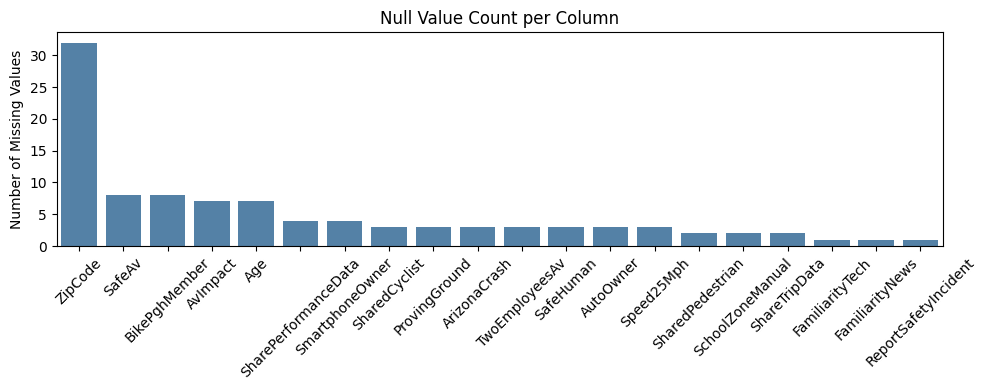

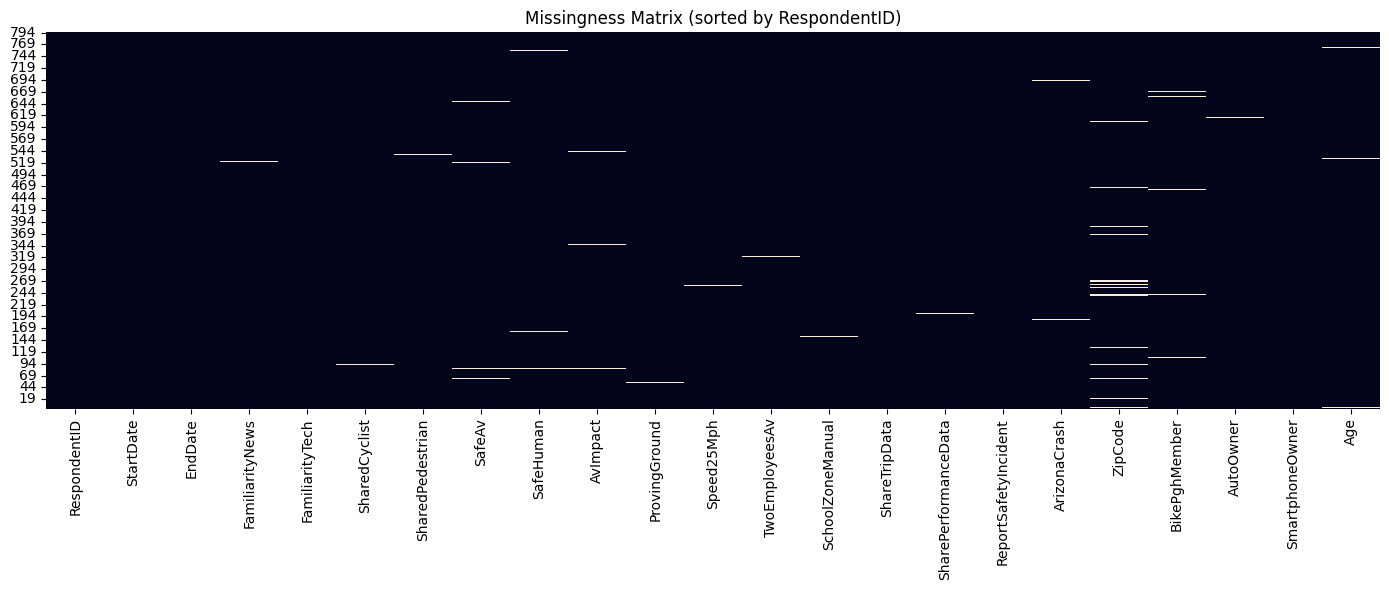

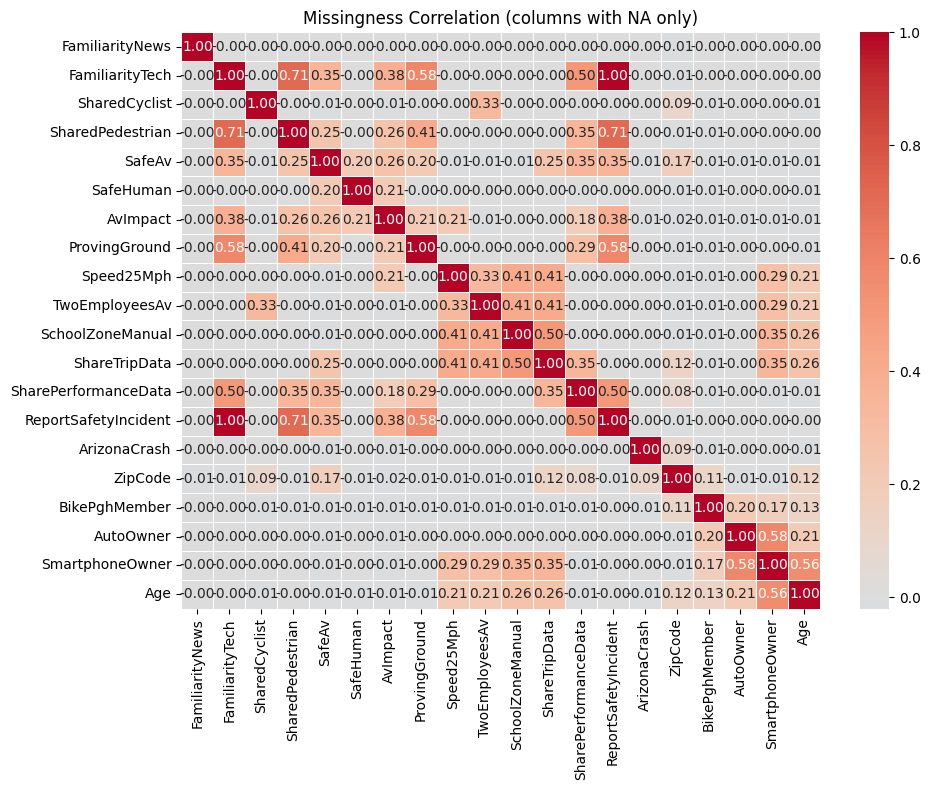

In [38]:
cols_with_na = df_av.columns[df_av.isnull().any()].tolist()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=miss_summary.index, y=miss_summary['n_missing'], color='steelblue', ax=ax) # plot bar chart of missing counts per column
ax.set_title('Null Value Count per Column')
ax.set_ylabel('Number of Missing Values')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df_av.sort_values('RespondentID').isna(), cbar=False, ax=ax) # visualize missingness pattern sorted by RespondentID
ax.set_title('Missingness Matrix (sorted by RespondentID)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

null_corr = df_av[cols_with_na].isnull().corr().round(2) # compute correlation of missingness between columns with NA only
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(null_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Missingness Correlation (columns with NA only)')
plt.tight_layout()
plt.show()



**Interpretation:**

`ZipCode` has the most missing values (32 out of 795, ~4%), visible as a dense column of white stripes in the matrix. All other columns have only 1–8 missing values (<1%).

The matrix shows missing values are **scattered randomly** across respondents there are no large blocks of missing data, which is consistent with MCAR.

The correlation heatmap reveals that some groups of survey questions tend to be missing **together**: `Speed25Mph`, `TwoEmployeesAv`, `SchoolZoneManual`, and `ShareTripData` show correlations of 0.33–0.50, suggesting respondents who skip one question in this group often skip the others as well. Similarly, `SmartphoneOwner` and `AutoOwner` co-occur as missing (ρ = 0.58).

---
## Task 2 – Is Missingness in `ZipCode` Related to Respondent Characteristics?

Examine whether the likelihood of `ZipCode` being missing depends on:
- **Age** of the respondent
- **Car ownership** (`AutoOwner`)
- **Smartphone ownership**

Use statistical tests (e.g. chi-square, t-test, logistic regression, or point-biserial correlation) and/or visualizations to support your analysis.

**Discuss the implications:** If missingness is related to one of these variables, what does that mean for the missingness mechanism (MCAR / MAR / MNAR)? How would this affect the validity of downstream analyses?

Age: chi2(6) = 7.474, p = 0.2792 
AutoOwner: chi2(1) = 0.324, p = 0.5694 
SmartphoneOwner: chi2(1) = 1.343, p = 0.2466 



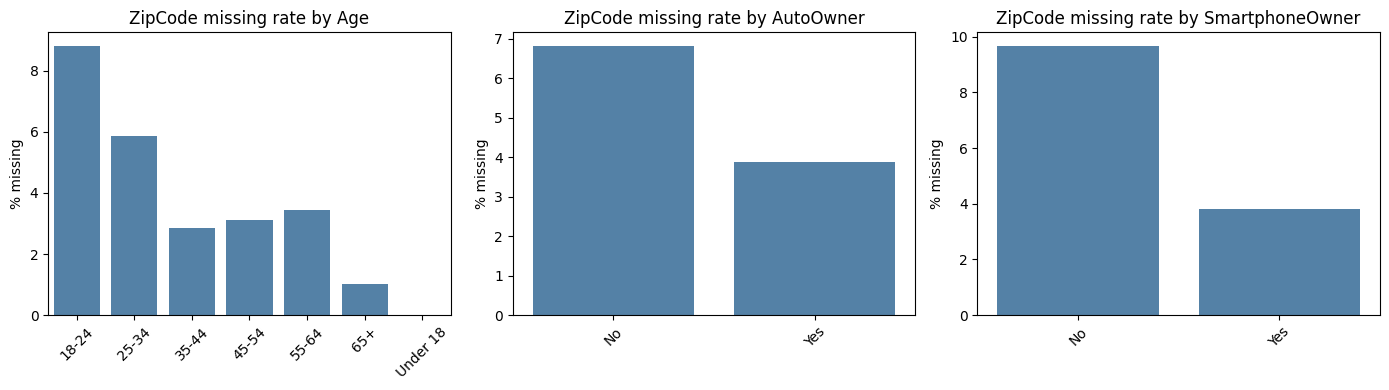

In [ ]:
from scipy.stats import chi2_contingency

df_av['ZipCode_missing'] = df_av['ZipCode'].isnull().astype(int) # create binary variable for missingness of ZipCode

for var in ['Age', 'AutoOwner', 'SmartphoneOwner']:
    subset = df_av[[var, 'ZipCode_missing']].dropna() # drop rows with NA in either variable
    ct = pd.crosstab(subset[var], subset['ZipCode_missing']) # create contingency table
    chi2, p, dof, _ = chi2_contingency(ct) # perform chi-squared test of independence
    sig = '*significant*' if p < 0.05 else '' # determine if result is statistically significant at alpha=0.05
    print(f'{var}: chi2({dof}) = {chi2:.3f}, p = {p:.4f} {sig}') # print results with chi-squared statistic, degrees of freedom, p-value, and significance indication

print()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ['Age', 'AutoOwner', 'SmartphoneOwner']):
    rate = df_av.groupby(var)['ZipCode_missing'].mean().mul(100).reset_index()
    rate.columns = [var, 'pct_missing']
    sns.barplot(data=rate, x=var, y='pct_missing', color='steelblue', ax=ax)
    ax.set_title(f'ZipCode missing rate by {var}')
    ax.set_ylabel('% missing')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**

None of the three variables show a significant relationship with ZipCode missingness (Age: p = 0.28, AutoOwner: p = 0.57, SmartphoneOwner: p = 0.25). This suggests the data is **MCAR**  the probability of ZipCode being missing does not depend on observed respondent characteristics. Analyses using only complete ZipCode records are therefore unlikely to introduce systematic bias.

---
## Task 3 – Compare Strategies for Handling Missing Data

Apply and compare four different approaches for handling missing values. After each approach, compute and compare **descriptive statistics and correlations** for the variables:
- `SafeAv`
- `BikePghMember`
- `AvImpact`
- `Age`

In [ ]:
category_orders = {
    'AvImpact': ['Significantly Worse', 'Slightly Worse', 'No effect', 'Slightly Better', 'Significantly Better'],
    'Age':      ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
} # define custom category order for plotting

### 3a – Complete Case Analysis (List-wise Deletion)

Drop all rows that contain at least one missing value. Compute descriptive statistics and correlations on the remaining data.

Rows remaining: 768 / 795 (27 dropped)


,SafeAv,BikePghMember,AvImpact,Age
count,768.000000,768,768,768
unique,NaN,3,5,7
top,NaN,Yes,Significantly Better,25-34
freq,NaN,378,302,201
mean,3.691406,NaN,NaN,NaN
std,1.188747,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3.000000,NaN,NaN,NaN
50%,4.000000,NaN,NaN,NaN
75%,5.000000,NaN,NaN,NaN


Correlation Matrix (listwise):


,SafeAv,BikePghMember,AvImpact,Age
SafeAv,1.000,0.067,0.650,-0.081
BikePghMember,0.067,1.000,0.040,0.116
AvImpact,0.650,0.040,1.000,-0.149
Age,-0.081,0.116,-0.149,1.000


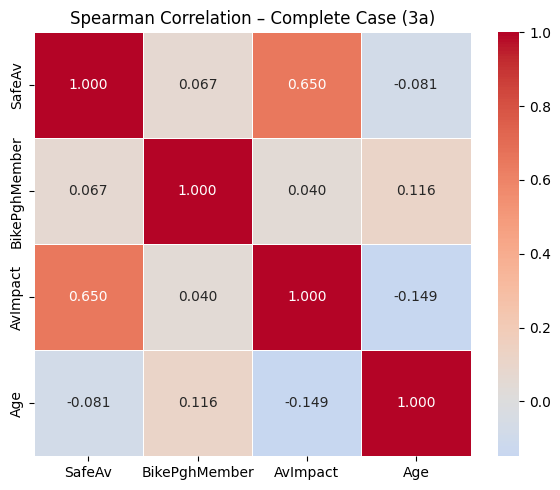

In [ ]:
focus_cols = ['SafeAv', 'BikePghMember', 'AvImpact', 'Age'] # select columns of interest for correlation analysis

enc_map = {
    'BikePghMember': {'No': 0, 'Not sure': 1, 'Yes': 2},
    'AvImpact':      {v: i for i, v in enumerate(category_orders['AvImpact'])},
    'Age':           {v: i for i, v in enumerate(category_orders['Age'])}
} 
 
df_complete = df_av[focus_cols].dropna() # create complete case dataset by dropping rows with NA in any of the focus columns (listwise deletion)
print(f'Rows remaining: {len(df_complete)} / {len(df_av)} ({len(df_av)-len(df_complete)} dropped)')

display(df_complete.describe(include='all'))

df_enc = df_complete.copy() # create a copy of the complete case dataset for encoding
for col, mapping in enc_map.items():
    df_enc[col] = df_enc[col].map(mapping) # encode categorical variables using the defined mapping (ordinal encoding for AvImpact and Age, custom encoding for BikePghMember)

corr_3a = df_enc.corr(method='spearman').round(3) # compute Spearman correlation matrix for the encoded complete case dataset and round to 3 decimal places
print('Correlation Matrix (listwise):')
display(corr_3a)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_3a, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax) # visualize the Spearman correlationmatrix using a heatmap with annotations
ax.set_title('Spearman Correlation – Complete Case (3a)')
plt.tight_layout()
plt.show()

**3a – Interpretation:**

27 rows were dropped, leaving 768 out of 795. The strongest correlation is between SafeAv and AvImpact (ρ = 0.65) — respondents who expect a more positive AV impact also rate them as safer. Age correlates weakly negative with SafeAv (ρ = -0.08) and AvImpact (ρ = -0.15), meaning older respondents tend to be slightly more skeptical. BikePghMember shows no meaningful correlation with any variable.

### 3b – Available Case Analysis (Pair-wise Deletion)

Use all available observations for each pairwise computation (e.g. correlations). Do not drop full rows — instead compute each statistic using only the non-missing values for the relevant variable(s).

,SafeAv,BikePghMember,AvImpact,Age
count,787.000000,787,788,788
unique,NaN,3,5,7
top,NaN,Yes,Significantly Better,25-34
freq,NaN,387,303,205
mean,3.679797,NaN,NaN,NaN
std,1.192272,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,3.000000,NaN,NaN,NaN
50%,4.000000,NaN,NaN,NaN
75%,5.000000,NaN,NaN,NaN


Correlation Matrix (pairwise):


,SafeAv,BikePghMember,AvImpact,Age
SafeAv,1.000,0.073,0.653,-0.085
BikePghMember,0.073,1.000,0.056,0.107
AvImpact,0.653,0.056,1.000,-0.158
Age,-0.085,0.107,-0.158,1.000


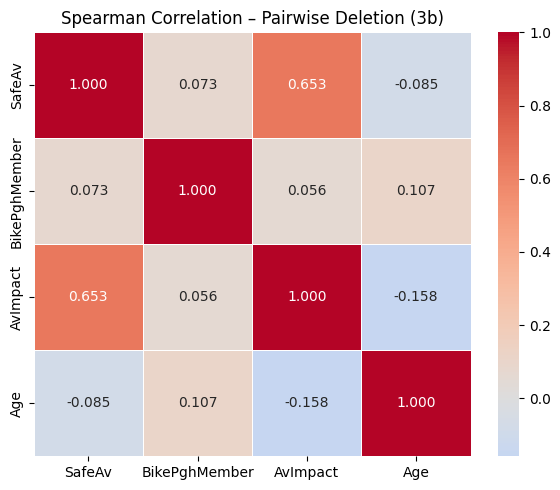

In [ ]:
display(df_av[focus_cols].describe(include='all')) 

df_av_enc = df_av[focus_cols].copy()# create a copy of the original dataset with focus columns for encoding and pairwise correlation analysis
for col, mapping in enc_map.items():
    df_av_enc[col] = df_av_enc[col].map(mapping) # encode the focus columns in the original dataset using the defined mapping (ordinal encoding for AvImpact and Age, custom encoding for BikePghMember) to make sure to keep NA values for pairwise correlation analysis

corr_3b = df_av_enc.corr(method='spearman', min_periods=1).round(3) # compute Spearman correlation matrix for the encoded original dataset using pairwise deletion (min_periods=1 allows using all available pairs of observations for each correlation) and round to 3 decimal places
print('Correlation Matrix (pairwise):')
display(corr_3b)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_3b, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax) # visualize the Spearman correlation matrix with pairwise deletion using a heatmap with annotations
ax.set_title('Spearman Correlation – Pairwise Deletion (3b)')
plt.tight_layout()
plt.show()

**3b – Interpretation:**

Using all non-missing pairs retains up to 795 observations per variable. The correlations are nearly identical to 3a (SafeAv – AvImpact: ρ = 0.65 in both). With only 7–8 missing values per column, both approaches yield the same conclusions.

### 3c – Single Imputation

Replace missing values with a single imputed value (e.g. mode for categorical, mean/median for numeric). Use `sklearn.impute.SimpleImputer` for efficiency. Justify your choice of imputation strategy.

Missing values after imputation: 0
SafeAv imputed with mean:        3.680
BikePghMember imputed with mode: Yes
AvImpact      imputed with mode: Significantly Better
Age           imputed with mode: 25-34

Descriptive statistics (single imputation):


,SafeAv,BikePghMember,AvImpact,Age
count,795.000,795.000,795.000,795.000
mean,3.680,1.083,2.926,3.541
std,1.186,0.951,1.156,1.470
min,1.000,0.000,0.000,0.000
25%,3.000,0.000,2.000,2.000
50%,4.000,1.000,3.000,3.000
75%,5.000,2.000,4.000,5.000
max,5.000,2.000,4.000,6.000



Correlation Matrix (single imputation):


,SafeAv,BikePghMember,AvImpact,Age
SafeAv,1.000,0.072,0.644,-0.079
BikePghMember,0.072,1.000,0.057,0.108
AvImpact,0.644,0.057,1.000,-0.146
Age,-0.079,0.108,-0.146,1.000


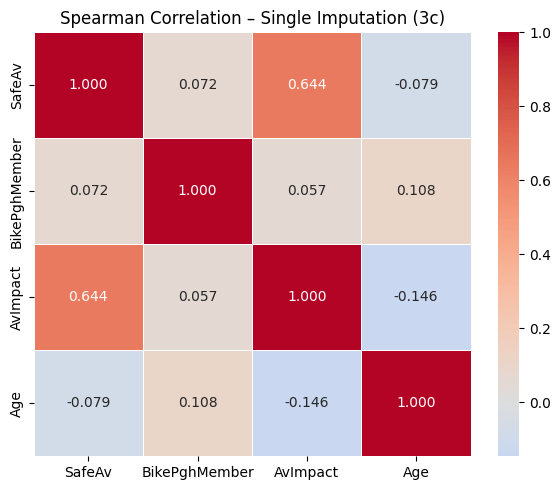

In [ ]:
from sklearn.impute import SimpleImputer

df_single = df_av[focus_cols].copy() # create a copy of the original dataset with focus columns for single imputation

num_imputer = SimpleImputer(strategy='mean') # define a SimpleImputer for numerical variables using mean imputation
cat_imputer = SimpleImputer(strategy='most_frequent') # define a SimpleImputer for categorical variables using mode imputation (most frequent value)

df_single[['SafeAv']] = num_imputer.fit_transform(df_single[['SafeAv']]) # impute missing values in the 'SafeAv' column using mean imputation and update the dataset with the imputed values
df_single[['BikePghMember', 'AvImpact', 'Age']] = cat_imputer.fit_transform(
    df_single[['BikePghMember', 'AvImpact', 'Age']] # impute missing values in the categorical columns using mode imputation and update the dataset with the imputed values
)

print(f'Missing values after imputation: {df_single.isnull().sum().sum()}')
print(f'SafeAv imputed with mean:        {num_imputer.statistics_[0]:.3f}')
print(f'BikePghMember imputed with mode: {cat_imputer.statistics_[0]}')
print(f'AvImpact      imputed with mode: {cat_imputer.statistics_[1]}')
print(f'Age           imputed with mode: {cat_imputer.statistics_[2]}')

df_single_enc = df_single.copy()
for col, mapping in enc_map.items():
    df_single_enc[col] = df_single_enc[col].map(mapping) # encode the imputed dataset using the defined mapping (ordinal encoding for AvImpact and Age, custom encoding for BikePghMember) to prepare for correlation analysis

print('\nDescriptive statistics (single imputation):')
display(df_single_enc.describe().round(3))

corr_3c = df_single_enc.corr(method='spearman').round(3) # compute Spearman correlation matrix for the encoded single imputation dataset and round to 3 decimal places
print('\nCorrelation Matrix (single imputation):')
display(corr_3c)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_3c, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax) # visualize the Spearman correlation matrix for the single imputation dataset using a heatmap with annotations
ax.set_title('Spearman Correlation – Single Imputation (3c)')
plt.tight_layout()
plt.show()

**3c – Single Imputation:**  
SafeAv was imputed with its mean (3.680), while BikePghMember, AvImpact, and Age were imputed
with their mode ("Yes", "Significantly Better", "25-34"). All 795 rows are now complete.
The SafeAv – AvImpact correlation stays at ρ = 0.64, nearly identical to the complete case result.
Single imputation can underestimate variance because all missing observations are pulled to the same fixed value,
which may slightly dampen correlations.

---
## Summary Comparison

Bring together the descriptive statistics and correlation results from all four approaches in a clear comparison table or visualization. Discuss:
- Which approach best preserves the original data distribution?
- Which approach introduces the most distortion?
- Which approach would you recommend for this dataset and why?

In [ ]:
print('SafeAv - AvImpact Spearman correlation across strategies:')
summary = {
    '3a Complete Case':     df_enc.corr(method='spearman').loc['SafeAv', 'AvImpact'],
    '3b Pairwise Deletion': df_av_enc.corr(method='spearman', min_periods=1).loc['SafeAv', 'AvImpact'],
    '3c Single Imputation': df_single_enc.corr(method='spearman').loc['SafeAv', 'AvImpact'],
}
for method, rho in summary.items():
    print(f'  {method:30s}: rho = {rho:.3f}')

print('\nSample sizes used:')
print(f'  3a Complete Case:        {len(df_enc)} rows')
print(f'  3b Pairwise Deletion:    up to {len(df_av_enc)} rows')
print(f'  3c Single Imputation:    {len(df_single_enc)} rows')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['3a Complete Case', '3b Pairwise', '3c Single Imp.']
corr_list = [corr_3a, corr_3b, corr_3c]
for ax, title, corr in zip(axes, titles, corr_list):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(title)
plt.suptitle('Spearman Correlation – Strategy Comparison', y=1.02)
plt.tight_layout()
plt.show()

**Summary:**

All three strategies produce a very similar SafeAv – AvImpact correlation (ρ ≈ 0.64–0.65), which is the strongest relationship in the dataset. The low number of missing values (7–8 per column out of 795, < 1.1%) means the choice of strategy has little practical impact here. Complete case and pairwise deletion give essentially the same result. Single imputation slightly reduces correlations toward zero by anchoring all missing values to one fixed value.